<img src="images\logo_iese.png" width="200" img style="float: right;"> 


<a id='index'></a>
__Index__

* [Installation guide](#install)
* [Claude Code inside VS Code](#_1)
    * [Adding context](#_1.1)
    * [Command Menu](#_1.2)
    * [Edits](#_1.3)
* [Prompt engineering for coding](#_2) 
* [Limitations and hallucinations](#_3)
* [Comments and documentation](#_4)
* [Multi-file context handling (scope)](#_5)
* [Debugging](#_6)
* [Refactoring](#_7)
* [Unit Testing](#_8)

Claude Code is an AI-powered coding assistant created by Anthropic, designed to support developers throughout the software development lifecycle. It uses advanced language models to understand natural language instructions and translate them into meaningful code, explanations, and suggestions.

You can always check your billing at: https://platform.claude.com/dashboard

## Arbitrary context - Data analysis

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd

# Excel is the analysis source. Put the workbook beside this notebook or in data/.
project_dir = Path.cwd()
excel_candidates = sorted(
    [*project_dir.glob("*.xlsx"), *project_dir.glob("*.xls"), *project_dir.glob("data/*.xlsx"), *project_dir.glob("data/*.xls")]
)
excel_path = excel_candidates[0] if excel_candidates else project_dir / "data" / "analysis_data.xlsx"

if not excel_path.exists():
    raise FileNotFoundError(
        f"Excel workbook not found. Add an .xlsx or .xls file beside the notebook or at {excel_path}."
    )

# Read the first sheet; the next cell reports all available sheets for transparency.
excel_sheets = pd.ExcelFile(excel_path).sheet_names
df = pd.read_excel(excel_path, sheet_name=excel_sheets[0])

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)
df = df.dropna(how="all").dropna(axis=1, how="all")

# Convert spreadsheet placeholders to missing values without changing numeric zeros.
df = df.replace({"?": np.nan, "NA": np.nan, "N/A": np.nan, "": np.nan})
df_original = df.copy(deep=True)

print(f"Loaded {excel_path.name!r}, sheet={excel_sheets[0]!r}, shape={df.shape}")
df.head()

FileNotFoundError: Excel workbook not found. Add an .xlsx or .xls file beside the notebook or at /Users/antoniocosta/Desktop/MIF/claude/data/analysis_data.xlsx.

[Back to index](#index)
<a id='install'></a>

## 0. Installation guide
You will need to have either a monthly license or a "pau as you go" credit via Claude Code API. 

1. Open Vs code and in the `Extensions` tab, search for `Claude`. You will find it with an `install` button. Click on it:

<img src="images//install_claude.png" width="400" img style="float: left;">

2. Once installed, you should see a `Claude`button next to the upper bar, at the top right. You are supposed to open your document normally (in this example, a jupyter notebook), and then, separately, open claude code chat.
<br>
<img src="images//install_claude_2.png" width="400" img style="float: left;">


[Back to index](#index)
<a id='_1'></a>

__1. Claude Code inside VS Code:__<br>
Overview of how Claude integrates into VS Code workflows. Explains how developers use AI to write, edit, and understand code.

This button allows you to add context to your session.
<img src="images//console_1.png" width="400" img style="float: left;">


In this example, we uploaded files of interest in our packaged code.
<img src="images//console_2.png" width="400" img style="float: left;">


[Back to index](#index)
<a id='_1.1'></a>

__1.1 Adding context:__<br>

And have introduced a very **generic** and **lazy** prompt:

<img src="images//console_3.png" width="400" img style="float: left;">

In [4]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 6.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 9.7 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [7]:
from my_toolbox import utils

In [ ]:
from my_toolbox import utils

# Excel workbook overview: use these tables to ground every later insight in observed data.
print("Sheets:", excel_sheets)
print("Rows and columns:", df.shape)
print("Duplicate rows:", int(df.duplicated().sum()))

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=True),
}).sort_values(["missing_pct", "unique"], ascending=[False, True])
profile

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

if numeric_cols:
    display(df[numeric_cols].describe().T.round(2))

if categorical_cols:
    categorical_summary = pd.DataFrame({
        "unique": df[categorical_cols].nunique(dropna=True),
        "top": [df[col].mode(dropna=True).iloc[0] if not df[col].mode(dropna=True).empty else np.nan for col in categorical_cols],
        "top_pct": [(df[col].value_counts(normalize=True, dropna=True).iloc[0] * 100).round(2) if not df[col].value_counts(normalize=True, dropna=True).empty else np.nan for col in categorical_cols],
    }, index=categorical_cols).sort_values("top_pct", ascending=False)
    display(categorical_summary)

# Visual 1: missingness and concentration reveal data-quality risks before modeling.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing = profile.query("missing > 0").head(15).sort_values("missing_pct")
if missing.empty:
    axes[0].text(0.5, 0.5, "No missing values", ha="center", va="center")
    axes[0].set_axis_off()
else:
    axes[0].barh(missing.index, missing["missing_pct"], color="#d95f59")
    axes[0].set_xlabel("Missing values (%)")
    axes[0].set_title("Missingness by column")

if numeric_cols:
    corr = df[numeric_cols].corr(numeric_only=True)
    sns.heatmap(corr, cmap="vlag", center=0, ax=axes[1])
    axes[1].set_title("Numeric correlation heatmap")
else:
    axes[1].text(0.5, 0.5, "No numeric columns", ha="center", va="center")
    axes[1].set_axis_off()
plt.tight_layout()
plt.show()

# Visual 2: distributions and outliers for the first six numeric measures.
if numeric_cols:
    df[numeric_cols[:6]].plot(kind="box", subplots=True, layout=(2, 3), figsize=(14, 7), sharex=False)
    plt.suptitle("Numeric distributions and potential outliers")
    plt.tight_layout()
    plt.show()

# Visual 3: the most concentrated categorical fields, useful for segmentation decisions.
plot_cols = [col for col in categorical_cols if 1 < df[col].nunique(dropna=True) <= 12][:4]
if plot_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, col in zip(axes.flat, plot_cols):
        counts = df[col].value_counts(dropna=False).head(10).sort_values()
        counts.plot.barh(ax=ax, color="#2a9d8f")
        ax.set_title(f"Top categories: {col}")
        ax.set_xlabel("Rows")
    for ax in axes.flat[len(plot_cols):]:
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# Optional target analysis: select an obvious binary target when the workbook has one.
target_candidates = [col for col in df.columns if col in {"target", "label", "outcome", "over50k", "y", "default"}]
if target_candidates:
    target = target_candidates[0]
    print(f"Target candidate: {target!r}")
    print((df[target].value_counts(dropna=False, normalize=True) * 100).round(2).rename("pct"))
    for col in categorical_cols[:6]:
        if col != target and 1 < df[col].nunique(dropna=True) <= 12:
            print(f"\nTarget rate by {col}:")
            display(df.groupby(col, dropna=False, observed=True)[target].agg(["count", "mean"]).sort_values("mean", ascending=False).head(10))
else:
    print("No conventional binary target column detected; compare segments using distributions and counts above.")

print("Suggested insight visuals:")
print("1. Missingness bar + correlation heatmap for data quality and relationships.")
print("2. Box plots or violin plots for numeric spread and outliers by key segments.")
print("3. Ranked bar charts for category size and, if a target exists, target rate by segment.")

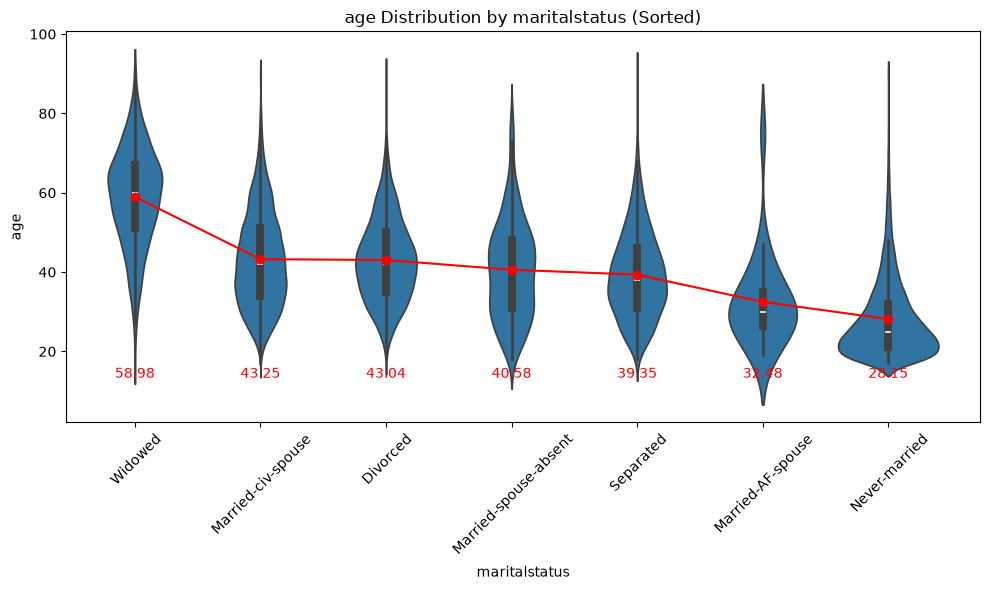

In [ ]:
# Optional Adult Census visual; skip it for workbooks with another schema.
if {"maritalstatus", "age"}.issubset(df.columns):
    utils.utils_viz.plot_cat2violin(df, categorical_col="maritalstatus", numerical_col="age")
else:
    print("Skipped marital-status/age plot: required columns are not present in the Excel workbook.")

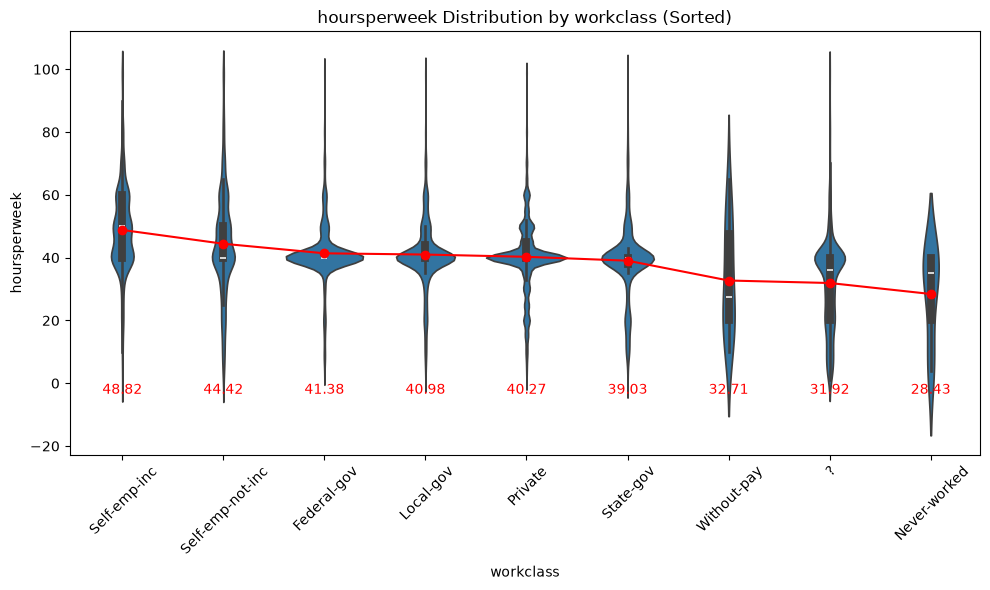

In [ ]:
# Optional Adult Census visual; skip it for workbooks with another schema.
if {"workclass", "hoursperweek"}.issubset(df.columns):
    utils.utils_viz.plot_cat2violin(df, categorical_col="workclass", numerical_col="hoursperweek")
else:
    print("Skipped workclass/hours plot: required columns are not present in the Excel workbook.")

Claude will even suggest cleaning transformations:

<img src="images//console_4.png" width="400" img style="float: left;">

__Comment:__ You can always check your billing subscription. Beeing specific and narrow when specifying your requirements will substantially decrease the billing because tokens would be less.

THe cost for this execution has been approximately **~ 0.75$**

[Back to index](#index)
<a id='_1.2'></a>

__1.2 Command menu:__<br>
- Clear conversation: Avoid circular logic and *missleading paths*
- Model: Is where the upgrade might come

<img src="images//console_5.png" width="400" img style="float: left;">

__1.3 Edits:__<br>
- Document edition**
- Effort (Id recommend set to low, if no edition)

<img src="images//console_6.png" width="400" img style="float: left;">

__Exercise:__ **prompt something to:** <br>
"Analyze the Adult Income dataset in this notebook using common pandas operations to explore tha dataset and utils.py to create the most informative visualizations."

Do it in the Claude Code window. <br>

Try to be as specific as possible. For example:

```text
Act as a senior data scientist.

Analyze the Adult Income dataset loaded in the notebook.

Requirements:

1. Perform an initial data audit
   - Shape
   - Data types
   - Missing values
   - Summary statistics

3. Explore the target variable (over50k)
   - Class balance
   - Key observations

4. Use functions from utils.py whenever appropriate rather than creating new visualization functions.
    - Explain why it was chosen.
   - Summarize the key finding.


5. For every visualization:
   
6. Conclude with:
   - Top 5 insights
   - Suggested feature engineering ideas
```

[Back to index](#index)
<a id='_2'></a>

__2. Prompt engineering for coding:__<br>
Teaches how to craft effective prompts. Focuses on clarity, context, and defining constraints for better outputs. You should change this files according to your project and add them to context.

**business_setting:** Explains business problem and goal. Provides functional details, restrictions.

**code_format:** Sticks to corporate standards

**target_role** Criticism

<img src="images//console_7.png" width="200" img style="float: left;">

[Back to index](#index)
<a id='_3'></a>

__3. Limitations and hallucinations:__<br>

A hallucination occurs when an AI generates information that sounds plausible and confident but is ~~factually incorrect~~, unsupported by the available data, or completely fabricated.

Hallucinations are especially dangerous because they can appear credible to users who do not verify the information.

Common examples include:
- Inventing data values
- Making up references or sources
- Generating incorrect calculations
- Creating fictitious business insights
- Claiming to have performed analyses that were never executed


```text
Suppose an analyst asks:

"Which customer segment generated the highest revenue last quarter?"

The dataset only contains customer demographics and transaction counts, but no revenue information.

A hallucinated response might be:

"The Enterprise segment generated $12.4 million in revenue last quarter, representing 34% year-over-year growth."


- The conclusion is unsupported by evidence.

```

__comment__ AI does not imitate human intelligence. Human reasoning is often wrong, yet widely accepted.

[Back to index](#index)
<a id='_4'></a>

__4. Comments and documentation:__<br>
Using Claude to generate clear comments and documentation. Improves readability and team collaboration. Uses **code_standard.md**

__Exercise:__ <br>
produce code so that i get columns for weight of evidence in occupation and education with respect to over50k.
    Ask the machine to comment not technical, but functional. Explaining the purpose of this transformation framed under a data analysis context.

In [ ]:
# We want to turn two descriptive fields, occupation and education, into numeric
# scores that reflect how strongly each category is associated with earning >50K.
# This lets a model use "how favorable is this occupation/education for high income"
# as a single, comparable number instead of many separate category labels.
event = df['over50k'].astype(str).str.strip().eq('>50K')

for col in ['occupation', 'education']:
    # For each category, count how many people earn >50K vs <=50K.
    grp = event.groupby(df[col], observed=True).agg(['sum', 'count'])

    # A small cushion (+0.5) avoids extreme scores for categories with very few
    # people, so a rare occupation with only one high earner isn't overstated.
    good = grp['sum'] + 0.5                      # people earning >50K in this category
    bad  = grp['count'] - grp['sum'] + 0.5        # people earning <=50K in this category

    # The score is positive when a category leans toward high income, negative
    # when it leans toward low income, and near zero when it's a mixed bag.
    woe  = np.log((good / good.sum()) / (bad / bad.sum()))
    df[f'{col}_woe'] = df[col].map(woe).astype(float)

# Preview: each person's original category next to its new income-association score.
df[['occupation', 'occupation_woe', 'education', 'education_woe']].head()


[Back to index](#index)
<a id='_5'></a>

__5. Multi-file context handling (scope):__<br>
If you add the whole project as context, every time you send a prompt the machine will go through the whole context. To narrow the search (and therefore, the cost) you can mention specificaly what files the machine should focus on.

Prompt like this:
```text
Review @directory/file_1.py and @file_2.py.

Do not use any other files unless I explicitly ask for them.
```

[Back to index](#index)
<a id='_6'></a>

__6. Debugging:__<br>
Using Claude to identify and fix basic bugs. Focuses on interpreting errors and suggesting fixes.

__Exercise:__ <br>
A business analyst says that the categories with the highest average values appear on the left in some reports and on the right in others.

Investigate the code and determine whether there is a bug. 

`hint`: add "Explain your reasoning and provide a fix if needed"

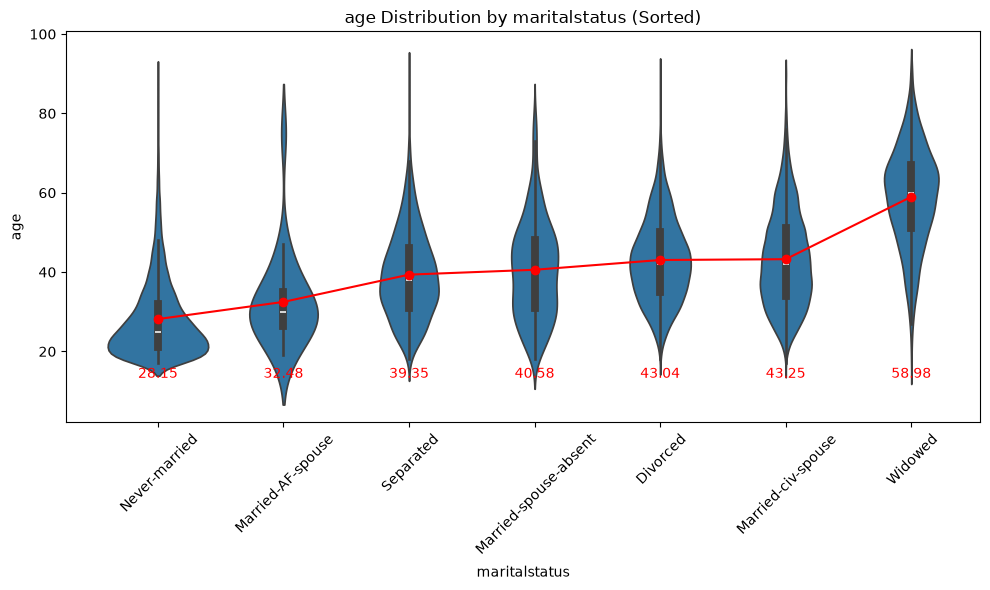

In [ ]:

utils.utils_viz.bugged_plot_cat2violin(df, categorical_col="maritalstatus", numerical_col="age")

__Expected outcome:__<br>

<img src="images//console_8.png" width="400" img style="float: left;">

[Back to index](#index)
<a id='_7'></a>

__7. Refactoring:__<br>
In software development, refactoring is the process of changing the internal structure of code without changing its external behavior.

The goal is to make the code:

- Easier to read
- Easier to maintain
- Easier to test
- More efficient to extend
- Less prone to bugs

__Example:__

```python
# original formula to calculate price with taxes
def f(x):
    return x * 1.21
```

In [ ]:
# YOUR SOLUTION HERE

```python
# refactored
TAX_RATE = 0.21

def calculate_price_with_tax(price):
    if price < 0:
        raise ValueError("Price cannot be negative")

    return price * (1 + TAX_RATE)
```

[Back to index](#index)
<a id='_6'></a>

__8. Unit Testing:__<br>

Unit testing is the practice of testing small, isolated pieces of code (called units, usually functions or methods) to verify that they behave as expected.

The goal is to answer questions like:

- Does the function return the correct result?
- Does it handle edge cases correctly?
- Does it fail when invalid input is provided?
- Did a code change accidentally break existing functionality?

In [ ]:
import pandas as pd

def get_category_means(df, categorical_col, numerical_col):

    return (
        df.groupby(categorical_col)[numerical_col].mean().sort_values(ascending=True)

        )

In [ ]:
def test_get_category_means(func):

    df = pd.DataFrame({
        "category": ["A", "A", "B", "B", "C", "C"],
        "value": [10, 20, 50, 60, 30, 40]
    })

    expected = ["B", "C", "A"]

    result = func(df, "category", "value")

    if list(result.index) == expected:
        return "OK"
    else:
        return f"KO - Expected {expected}, got {list(result.index)}"

In [ ]:
test_get_category_means(get_category_means)

"KO - Expected ['B', 'C', 'A'], got ['A', 'C', 'B']"